## 0. Chuẩn bị môi trường

Phần này nạp các thư viện cần dùng và cấu hình notebook để có thể import code từ thư mục gốc của project.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))

### Giải thích cell import đầu tiên

Cell này chỉ làm 2 việc: bật tự động nạp lại module khi bạn sửa code trong project, và thêm thư mục cha vào `sys.path` để notebook có thể import được `models` và `utils`.

Output thực tế của cell này là không in ra số liệu nào; nếu chạy thành công thì coi như notebook đã sẵn sàng để dùng lại các file trong project mà không cần restart kernel. Nếu có lỗi thì thường là do notebook chưa đứng đúng thư mục hoặc đường dẫn project chưa hợp lệ.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from models.MLP.model import MLP
from utils.loss.BCELoss import BCELoss
from utils.optimizers.Adam import Adam

### Giải thích cell import thư viện

Cell này import toàn bộ thư viện bên ngoài và các class tự viết trong project:
- `numpy` để xử lý dữ liệu dạng mảng.
- `matplotlib` để vẽ biểu đồ loss.
- `train_test_split`, `StandardScaler`, `accuracy_score` từ scikit-learn để chia dữ liệu, chuẩn hoá, và đánh giá.
- `MLP`, `BCELoss`, `Adam` là các thành phần chính của mô hình.

Output thực tế của cell này cũng không có text in ra màn hình. Ý nghĩa của nó là chuẩn bị đủ công cụ để các cell sau gọi trực tiếp được các hàm/lớp này. Nếu import lỗi, thường là do thiếu package hoặc class trong project chưa đúng tên.

## 1. Load real data (Pima Indians Diabetes)

CSV has no header. Columns: Pregnancies, Glucose, BloodPressure, SkinThickness,
Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome (0/1 target).

In [3]:
DATA_PATH = r"D:\Project\Dataset\Medical\pima-indians-diabetes.csv"

data = np.loadtxt(DATA_PATH, delimiter=",")
X = data[:, :-1]
y = data[:, -1:]  # keep shape (n, 1) to match model output shape

print("X shape:", X.shape, "y shape:", y.shape)
print("Class balance (fraction positive):", y.mean())

X shape: (768, 8) y shape: (768, 1)
Class balance (fraction positive): 0.3489583333333333


### Giải thích cell nạp dữ liệu

Cell này đọc file CSV bằng `np.loadtxt`, tách phần đặc trưng vào `X` và nhãn mục tiêu vào `y`.

Output thực tế khi chạy cell này là:
- `X shape: (768, 8)` nghĩa là dữ liệu có 768 mẫu và 8 feature đầu vào.
- `y shape: (768, 1)` nghĩa là mỗi mẫu có một nhãn nhị phân, đúng kiểu đầu ra của mô hình.
- `Class balance (fraction positive): 0.3489583333333333` nghĩa là khoảng 34.9% mẫu mang nhãn 1. Dữ liệu hơi lệch về lớp 0, nhưng chưa đến mức quá nghiêm trọng.

Nếu đường dẫn `DATA_PATH` sai, cell sẽ báo lỗi đọc file ngay ở bước này.

## 2. Train/test split + feature scaling

The Linear layer's weight init assumes roughly unit-variance inputs, and raw
features here have very different scales (e.g. Insulin 0-800 vs BMI 0-60).
Without scaling, training will be slow/unstable. Fit the scaler on train only
to avoid leaking test statistics.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (614, 8) Test: (154, 8)


### Giải thích cell chia train/test và chuẩn hoá

Cell này tách dữ liệu thành tập train và test, sau đó chuẩn hoá feature bằng `StandardScaler`.

Output thực tế của cell này là `Train: (614, 8) Test: (154, 8)`. Điều đó có nghĩa là 614 mẫu được dùng để học và 154 mẫu được giữ lại để kiểm tra mô hình.

Việc scale dữ liệu rất quan trọng vì các cột như `Insulin`, `BMI`, `Age` có thang đo rất khác nhau. Nếu không chuẩn hoá, quá trình học của mạng có thể chậm hoặc kém ổn định.

Lưu ý rằng scaler chỉ được fit trên train để tránh rò rỉ thông tin từ test.

## 3. Build model, loss, optimizer

Binary classification -> `sigmoid` activation (keeps output in (0,1)) + `BCELoss`.

In [5]:
net = MLP(input_dim=X_train.shape[1], hidden_dims=[16, 8], output_dim=1, activation='sigmoid')
loss_fn = BCELoss()
optimizer = Adam(net.parameters(), lr=0.01)

### Giải thích cell khởi tạo mô hình

Cell này tạo mô hình `MLP`, hàm loss `BCELoss`, và optimizer `Adam`.

Output thực tế của cell này không in ra text nào. Ý nghĩa của nó là tạo ra 3 đối tượng dùng cho toàn bộ quá trình học tiếp theo.

Ý nghĩa từng phần:
- `input_dim=X_train.shape[1]`: số đầu vào bằng số cột feature.
- `hidden_dims=[16, 8]`: mạng có 2 lớp ẩn, lần lượt 16 và 8 neuron.
- `output_dim=1`: bài toán nhị phân nên đầu ra chỉ có 1 giá trị xác suất.
- `activation='sigmoid'`: đảm bảo output nằm trong khoảng 0 đến 1.
- `BCELoss`: đo độ lệch giữa xác suất dự đoán và nhãn thật.
- `Adam`: thuật toán cập nhật trọng số.

Sau cell này, bạn đã có đối tượng mô hình để train ở cell tiếp theo.

## 4. Train (full-batch gradient descent)

The current optimizer/loss classes don't do mini-batching, so each "step" here
is a full pass over the whole training set.

In [7]:
n_epochs = 300
loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    pred = net(X_train)
    loss = loss_fn(pred, y_train)
    loss_history.append(loss)

    grad_loss = loss_fn.backward()
    net.backward(grad_loss)
    optimizer.step()

    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:4d} — loss: {loss:.4f}")

Epoch    0 — loss: 0.3016
Epoch   50 — loss: 0.2478
Epoch  100 — loss: 0.2031
Epoch  150 — loss: 0.1664
Epoch  200 — loss: 0.1358
Epoch  250 — loss: 0.1126
Epoch  299 — loss: 0.0908


### Giải thích cell train mô hình

Cell này chạy full-batch training trong `n_epochs` vòng lặp.

Cách đọc logic bên trong:
- `optimizer.zero_grad()` xoá gradient cũ trước mỗi bước học.
- `pred = net(X_train)` chạy forward pass để lấy dự đoán.
- `loss = loss_fn(pred, y_train)` tính BCE loss giữa dự đoán và nhãn thật.
- `grad_loss = loss_fn.backward()` lấy gradient của loss.
- `net.backward(grad_loss)` truyền gradient ngược qua mạng.
- `optimizer.step()` cập nhật trọng số.

Output thực tế của cell này là chuỗi loss giảm dần theo epoch:
- `Epoch    0 — loss: 0.3016`
- `Epoch   50 — loss: 0.2478`
- `Epoch  100 — loss: 0.2031`
- `Epoch  150 — loss: 0.1664`
- `Epoch  200 — loss: 0.1358`
- `Epoch  250 — loss: 0.1126`
- `Epoch  299 — loss: 0.0908`

Dãy số này cho thấy mô hình đang học tốt hơn trên train set, vì loss giảm đều từ 0.3016 xuống 0.0908. `loss_history` được lưu để vẽ biểu đồ ở cell sau.

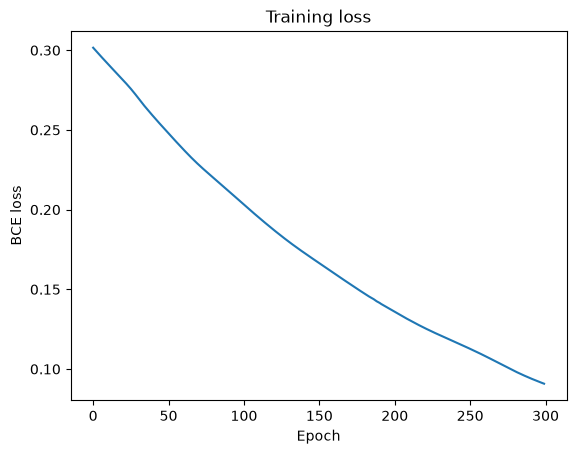

In [8]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Training loss")
plt.show()

### Giải thích cell vẽ loss

Cell này dùng `loss_history` để vẽ đường cong học tập của mô hình.

Output thực tế của cell là một biểu đồ đường. Vì `loss_history` bắt đầu từ 0.3016 và kết thúc ở 0.0908, nên đường cong sẽ đi xuống khá rõ.

Ý nghĩa của biểu đồ:
- Trục `Epoch` là số vòng lặp train.
- Trục `BCE loss` là giá trị lỗi trung bình ở mỗi epoch.
- Đường cong đi xuống và ổn định cho thấy mô hình đang hội tụ tốt hơn.
- Nếu loss dao động mạnh hoặc không giảm, có thể cần đổi learning rate, kiến trúc mạng, hoặc cách chuẩn hoá dữ liệu.

## 5. Evaluate on the held-out test set

In [9]:
test_pred = net(X_test)
test_pred_labels = (test_pred >= 0.5).astype(int)

acc = accuracy_score(y_test, test_pred_labels)
test_loss = loss_fn(test_pred, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {acc:.4f}")

Test loss: 1.6581
Test accuracy: 0.6818


### Giải thích cell đánh giá trên test set

Cell này chạy mô hình trên dữ liệu test để xem mô hình tổng quát hóa tốt đến đâu.

Output thực tế của cell là:
- `Test loss: 1.6581`
- `Test accuracy: 0.6818`

Cách đọc output:
- `test_pred = net(X_test)` trả về xác suất dự đoán cho từng mẫu.
- `test_pred_labels = (test_pred >= 0.5).astype(int)` đổi xác suất thành nhãn 0/1.
- `test_loss = 1.6581` cho biết chất lượng dự đoán xác suất trên toàn bộ test set; giá trị này cao hơn loss train nên mô hình còn khoảng cách tổng quát hóa.
- `acc = 0.6818` nghĩa là mô hình dự đoán đúng khoảng 68.18% mẫu test.

Nếu `test_loss` cao nhưng `acc` vẫn ở mức trung bình như ở đây, mô hình có thể đang dự đoán chưa thật chắc ở một số mẫu, hoặc ngưỡng 0.5 chưa phải tối ưu nhất cho dữ liệu này.

### Giải thích output của phần đánh giá

- `test_pred = net(X_test)` tạo ra xác suất dự đoán cho từng mẫu trong tập test. Vì đầu ra của mô hình là sigmoid nên giá trị nằm trong khoảng 0 đến 1.
- `test_pred_labels = (test_pred >= 0.5).astype(int)` đổi xác suất thành nhãn nhị phân. Mẫu nào có xác suất lớn hơn hoặc bằng 0.5 sẽ được xem là dự đoán bị tiểu đường (`1`), ngược lại là không bị tiểu đường (`0`).
- `test_loss` là BCE loss trên toàn bộ tập test. Chỉ số này cho biết mô hình dự đoán xác suất có sát với nhãn thật hay không; giá trị càng thấp càng tốt.
- `acc` là độ chính xác, tức tỷ lệ dự đoán đúng sau khi đã chuyển xác suất thành nhãn. Chỉ số này dễ đọc hơn, nhưng không phản ánh mức độ “tự tin” của mô hình như `test_loss`.

Nếu `test_loss` giảm nhưng `acc` chưa tăng nhiều, điều đó thường có nghĩa là mô hình đang cải thiện chất lượng xác suất trước khi nhãn phân loại thay đổi rõ rệt.

### Thêm dữ liệu để test thủ công

Cell tiếp theo cho phép bạn nhập thêm một vài mẫu mới để kiểm tra mô hình. Những mẫu này không dùng để train, cũng không làm thay đổi `X_test`; mục tiêu chỉ là xem mô hình phản ứng thế nào với đầu vào khác nhau và đọc trực tiếp xác suất dự đoán.

### Giải thích cell test thủ công

Cell này tạo một vài mẫu mới để thử mô hình sau khi train xong.

Output thực tế của cell là:
- Sample 1: xác suất 0.0290, nhãn dự đoán 0.
- Sample 2: xác suất 1.0000, nhãn dự đoán 1.
- Sample 3: xác suất 0.0001, nhãn dự đoán 0.

Điều này cho thấy mô hình đang phản ứng rất mạnh với từng mẫu đầu vào: mẫu 2 được xem là có nguy cơ cao, còn mẫu 1 và 3 được xem là không thuộc lớp dương tính.

Phần này giúp bạn kiểm tra mô hình trên dữ liệu do chính bạn chọn, thay vì chỉ nhìn vào train/test metrics.

In [13]:
custom_samples = np.array([
    [2, 120, 70, 28, 0, 32.0, 0.45, 33],
    [6, 168, 74, 30, 0, 38.0, 0.54, 49],
    [1, 95, 66, 18, 0, 24.0, 0.20, 22],
], dtype=float)

custom_samples_scaled = scaler.transform(custom_samples)
custom_pred = net(custom_samples_scaled)
custom_pred_labels = (custom_pred >= 0.5).astype(int)

for i, (sample, prob, label) in enumerate(zip(custom_samples, custom_pred, custom_pred_labels), start=1):
    prob_value = np.asarray(prob).reshape(-1)[0]
    label_value = np.asarray(label).reshape(-1)[0]
    print(f"Sample {i}: {sample}")
    print(f"  Predicted probability: {prob_value:.4f}")
    print(f"  Predicted label: {int(label_value)}")
    print()

Sample 1: [  2.   120.    70.    28.     0.    32.     0.45  33.  ]
  Predicted probability: 0.0290
  Predicted label: 0

Sample 2: [  6.   168.    74.    30.     0.    38.     0.54  49.  ]
  Predicted probability: 1.0000
  Predicted label: 1

Sample 3: [ 1.  95.  66.  18.   0.  24.   0.2 22. ]
  Predicted probability: 0.0001
  Predicted label: 0

